### Read buffered tiff and corresponding txt

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# notebook/ 的父目录
root = Path.cwd().parent 
sys.path.insert(0, str(root))

from utils_io import load_buffer_frames_and_angles

#auto reload
%load_ext autoreload
%autoreload 2


In [2]:
txt_path= r"D:\data\ImagingData\TIFF Export\online_grab_CH2_20260127_124807_time.txt"
tif_path = r"D:\data\ImagingData\TIFF Export\online_grab_CH2_20260127_124807.tif"
rotary_log_path = r"D:\data\ImagingData\TIFF Export\rotary_stream_20260211_114354.txt"

# img, frame_indices, monotonic_secs = load_tiff_and_time(tif_path, txt_path)
# angle_at_mono= get_angles_from_monotonic_slice(monotonic_secs, rotary_log_path)

frames, angles = load_buffer_frames_and_angles(tif_path, txt_path, rotary_log_path)

## register to zstack

In [3]:
from suite2p.registration import zalign
import tifffile
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import torch
# notebook/ 的父目录
root = Path.cwd().parent 
sys.path.insert(0, str(root))

from utils_image import get_meanframe_from_Zstacks_cv2, get_unrotate_crop_cv2
from utils_io import get_frame_angles_from_rotary
from suite2p.registration import zalign

In [4]:
tif_path = r"D:\data\test\stack_00001.tif"
rotary_log_path = r"D:\data\test\rotary_stream_20260211_114354.txt"
angles, _, _ = get_frame_angles_from_rotary(tif_path, rotary_log_path)

In [5]:

frames = tifffile.imread(tif_path)


w = frames.shape[-1]
h = frames.shape[-2]
frames = frames.reshape(-1, w, h)

Rotcenter = [248,236]
volume = 1; stacks=41; frames_per_stack=200

device = torch.device("cuda")
meanZstacks_cv = get_meanframe_from_Zstacks_cv2(frames, angles, volume, stacks, frames_per_stack, Rotcenter, ImgReg=False, device=device)

Extract the mean frame of Zstacks (OpenCV)...
Processing stack 0
Stack 1 done. Time used: 1.87 sec
Processing stack 1
Stack 2 done. Time used: 0.20 sec
Processing stack 2
Stack 3 done. Time used: 0.18 sec
Processing stack 3
Stack 4 done. Time used: 0.21 sec
Processing stack 4
Stack 5 done. Time used: 0.19 sec
Processing stack 5
Stack 6 done. Time used: 0.19 sec
Processing stack 6
Stack 7 done. Time used: 0.21 sec
Processing stack 7
Stack 8 done. Time used: 0.19 sec
Processing stack 8
Stack 9 done. Time used: 0.19 sec
Processing stack 9
Stack 10 done. Time used: 0.21 sec
Processing stack 10
Stack 11 done. Time used: 0.20 sec
Processing stack 11
Stack 12 done. Time used: 0.23 sec
Processing stack 12
Stack 13 done. Time used: 0.21 sec
Processing stack 13
Stack 14 done. Time used: 0.21 sec
Processing stack 14
Stack 15 done. Time used: 0.21 sec
Processing stack 15
Stack 16 done. Time used: 0.19 sec
Processing stack 16
Stack 17 done. Time used: 0.19 sec
Processing stack 17
Stack 18 done. Tim

In [6]:
frames = tifffile.imread(tif_path)
w = frames.shape[-1]
h = frames.shape[-2]
frames = frames.reshape(-1, w, h)
frames_crop = get_unrotate_crop_cv2(frames, angles, Rotcenter)
frames_crop.shape




(8200, 332, 332)

In [ ]:
refImgs = [meanZstacks_cv[z] for z in range(meanZstacks_cv.shape[0])]


(332, 332)

In [35]:
device = torch.device("cuda")
frames_selected = frames_crop[::100]
cmax_all = zalign.register_to_zstack(f_align_in=frames_selected, refImgs=refImgs, nonrigid=True, device=device)

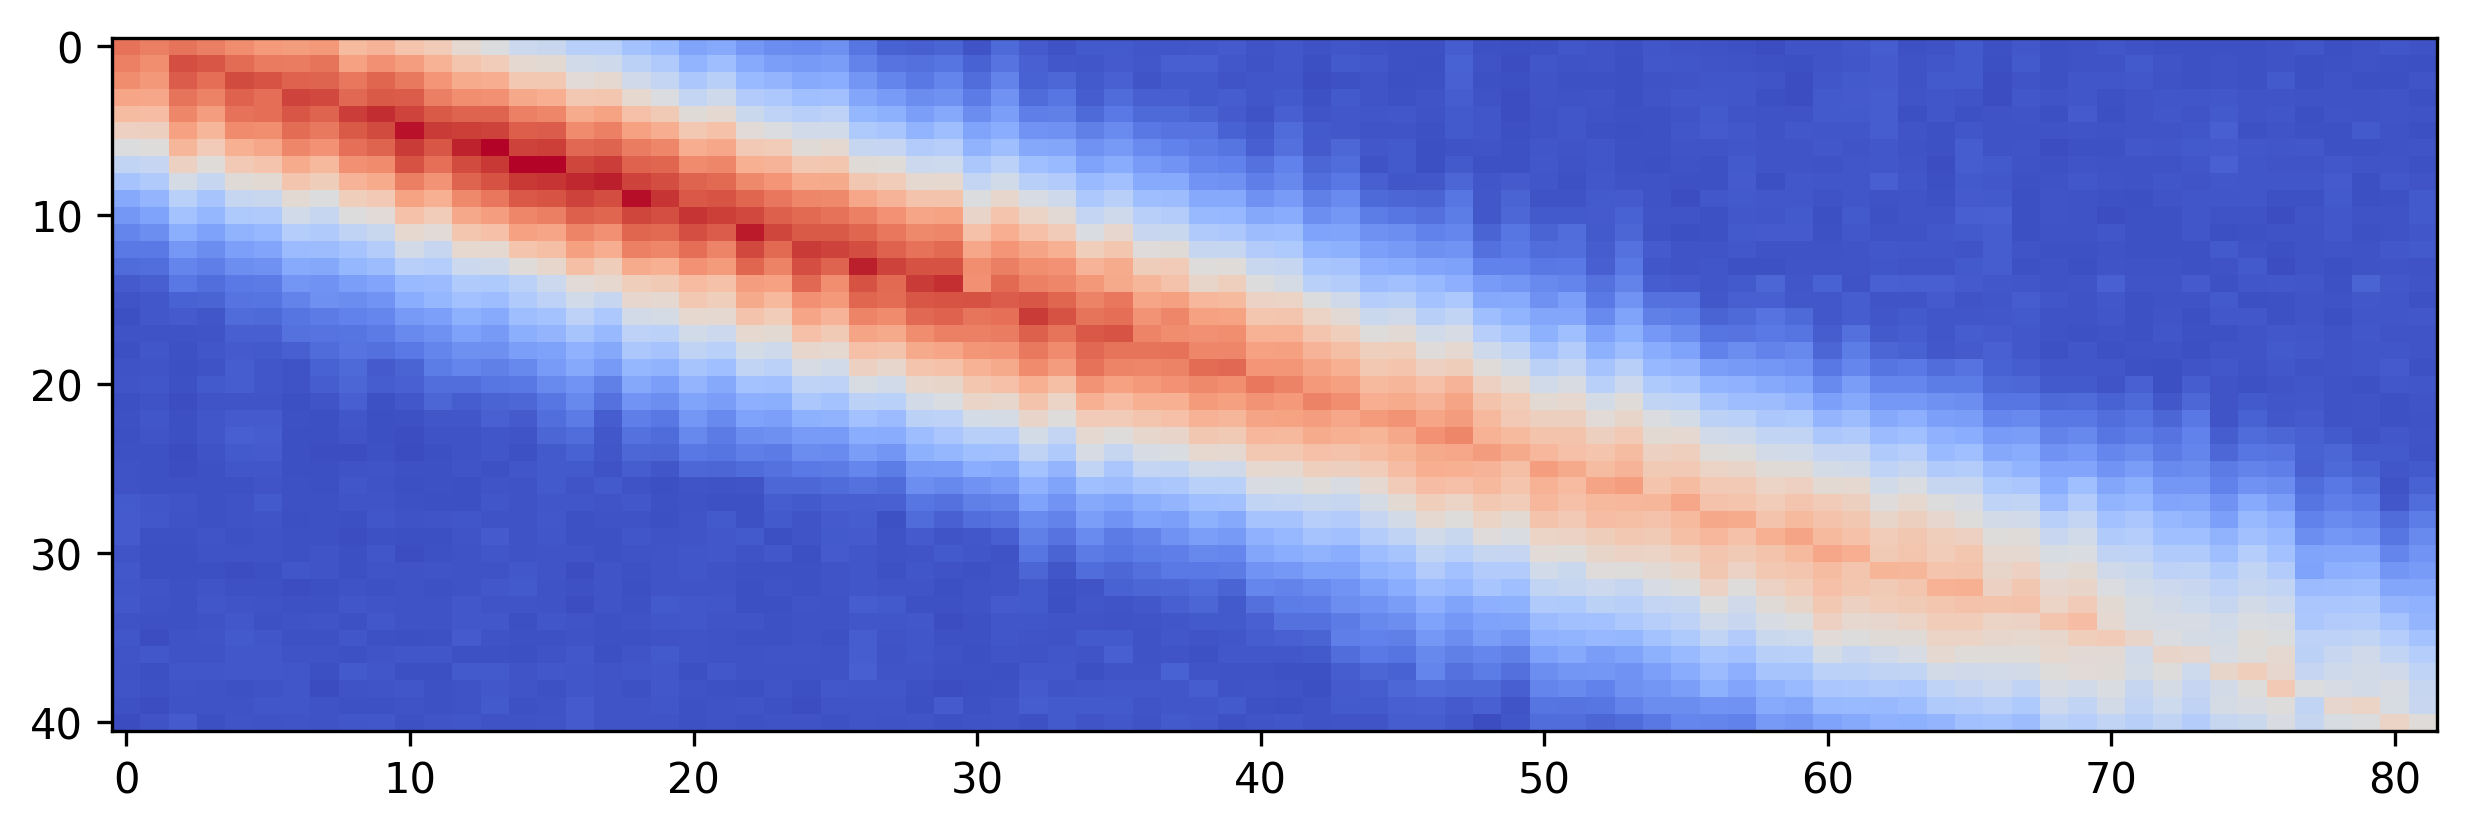

In [36]:
fig, ax = plt.subplots(figsize=(10, 3),dpi=300)
plt.imshow(cmax_all.T, cmap='coolwarm', aspect='auto')